In [1]:
# !pip install prophet

In [2]:
# import pandas as pd
# import numpy as np
# from prophet import Prophet
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import matplotlib.pyplot as plt

# # 1. Data Loading and Initial Preparation
# df = pd.read_csv("drought_focasting_data.csv")

# # Replace with actual start date and correct frequency (e.g., daily = 'D')
# df['ds'] = pd.date_range(start='2014-09-01', periods=len(df), freq='D')
# df['ds'] = pd.to_datetime(df['ds'])
# df.set_index('ds', inplace=True)



# # Rename target
# df.rename(columns={'precip': 'y'}, inplace=True)



# # Handle missing values
# print("Missing values before imputation:\n", df.isnull().sum())

# # For the target variable, let's use forward fill (better than mean for time series)
# df['y'].fillna(method='ffill', inplace=True)

# # For other features, use interpolation
# df['temp'].interpolate(method='time', inplace=True)
# df['humidity'].interpolate(method='time', inplace=True)
# df['windspeed'].interpolate(method='time', inplace=True)

# print("\nMissing values after imputation:\n", df.isnull().sum())



import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Data Loading and Initial Preparation
df = pd.read_csv("drought_focasting_data.csv")

# Rename target first
df.rename(columns={'precip': 'y'}, inplace=True)

# Create 'ds' column for Prophet
df['ds'] = pd.date_range(start='2014-09-01', periods=len(df), freq='D')
df['ds'] = pd.to_datetime(df['ds'])

# Set 'ds' as index for time-based operations
# df.set_index('ds', inplace=True)
# df.set_index({'col': 'ds'}, inplace=True)
df = df.set_index('ds')
# df['ds'] = df['ds'].set_index()

# Handle missing values
print("Missing values before imputation:\n", df.isnull().sum())

# Forward fill for target variable
df['y'].fillna(method='ffill', inplace=True)

# Time-based interpolation for features
df['temp'].interpolate(method='time', inplace=True)
df['humidity'].interpolate(method='time', inplace=True)
df['windspeed'].interpolate(method='time', inplace=True)

print("\nMissing values after imputation:\n", df.isnull().sum())
# print(df.index)

# Reset index to get 'ds' back as a column
# df.reset_index('ds',inplace=True)
# df.reset_index({'col': 'ds'}, inplace=True)
# df = df.reset_index('ds')
df = df.reset_index()
# df['ds'] = df['ds'].reset_index('ds')
    
# Ensure correct column order for Prophet and modeling
df = df[['ds', 'y', 'temp', 'humidity', 'windspeed']]

# Final check
print("\nFinal columns:", df.columns)



Missing values before imputation:
 temp          0
humidity      0
y            10
windspeed     0
dtype: int64

Missing values after imputation:
 temp         0
humidity     0
y            0
windspeed    0
dtype: int64

Final columns: Index(['ds', 'y', 'temp', 'humidity', 'windspeed'], dtype='object')


In [3]:
# df.reset_index(inplace=True)

# # Reorder for Prophet
# df = df[['ds', 'y', 'temp', 'humidity', 'windspeed']]

In [4]:
print(df.columns)

Index(['ds', 'y', 'temp', 'humidity', 'windspeed'], dtype='object')


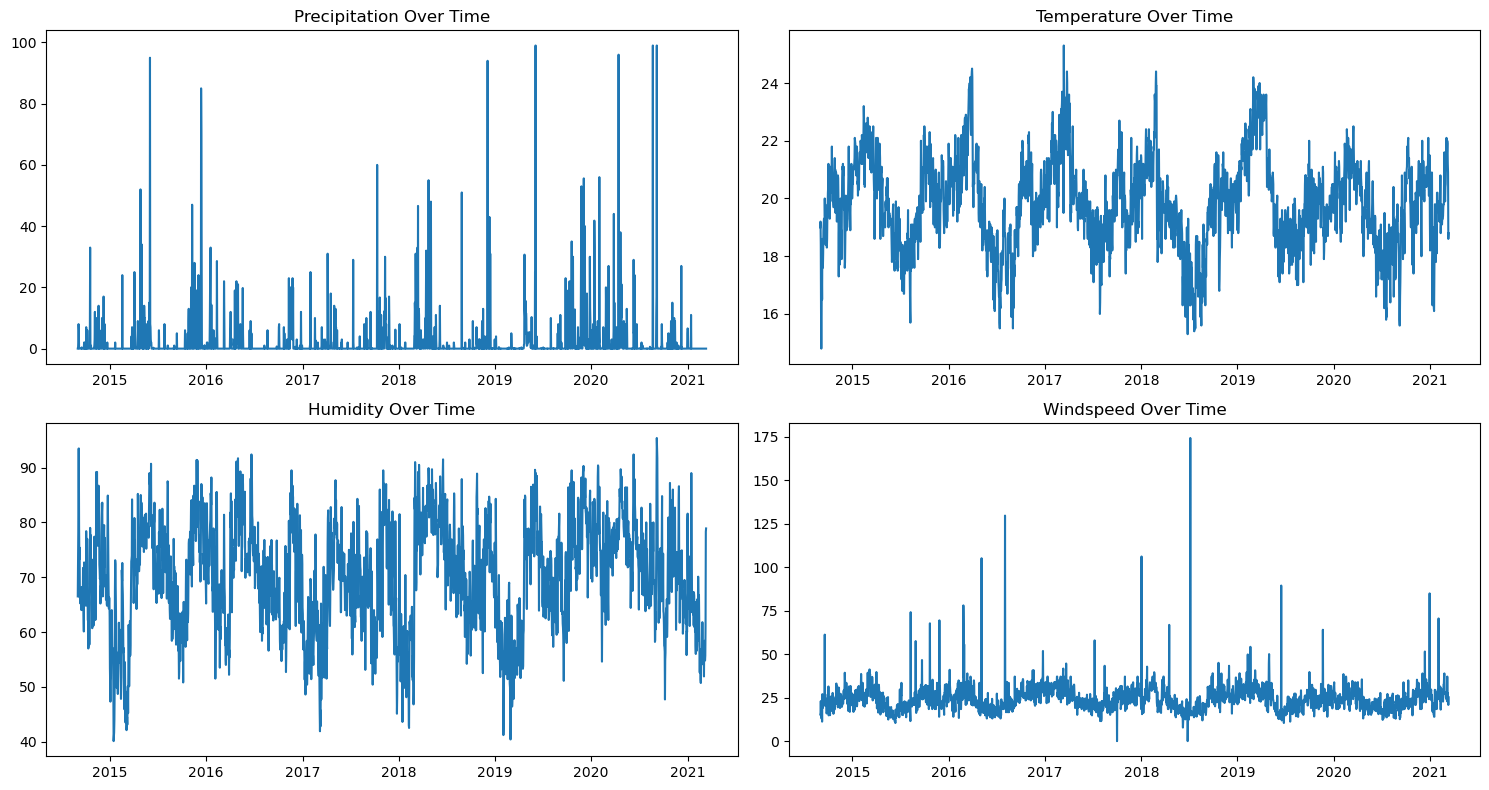

In [5]:
# 2. Exploratory Data Analysis
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.plot(df['ds'], df['y'])
plt.title('Precipitation Over Time')

plt.subplot(2, 2, 2)
plt.plot(df['ds'], df['temp'])
plt.title('Temperature Over Time')

plt.subplot(2, 2, 3)
plt.plot(df['ds'], df['humidity'])
plt.title('Humidity Over Time')

plt.subplot(2, 2, 4)
plt.plot(df['ds'], df['windspeed'])
plt.title('Windspeed Over Time')
plt.tight_layout()
plt.show()



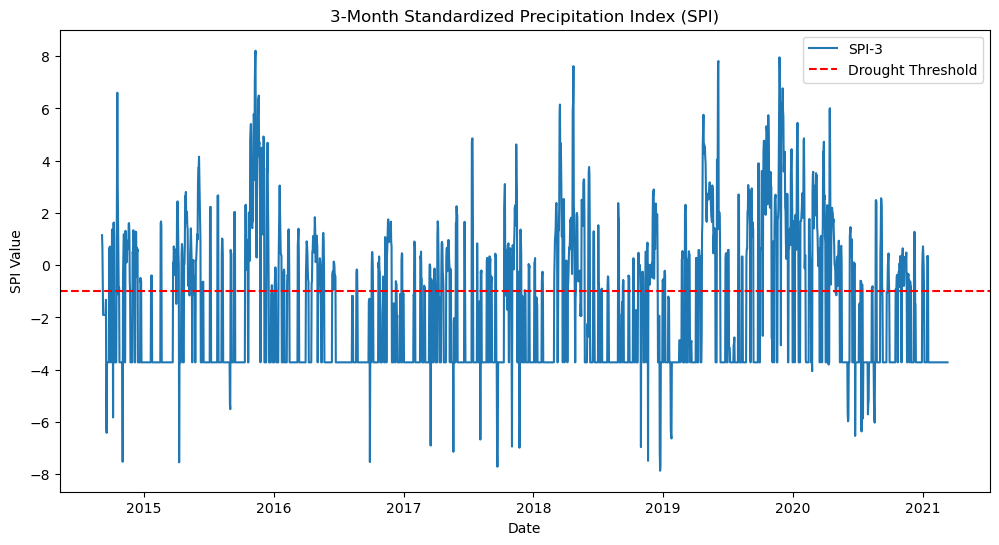

In [6]:
# 3. Calculate SPI (Standardized Precipitation Index)
from scipy import stats
import numpy as np

def calculate_spi(precip_series, scale=3):
    """Calculate Standardized Precipitation Index (SPI)"""
    rolling_sum = precip_series.rolling(window=scale, min_periods=scale).sum()

    spi_values = []
    for i in range(len(rolling_sum)):
        if i < scale - 1:
            spi_values.append(np.nan)
        else:
            # Fit gamma distribution to historical data
            hist_data = rolling_sum[:i+1].dropna()

            # Handle zero and negative values by adding a small positive constant:
            hist_data = hist_data[hist_data > 0] #Filter data to avoid 0 or negative value
            if len(hist_data) < scale : #if data less than scale, then pass
                spi_values.append(np.nan)
                continue


            params = stats.gamma.fit(hist_data) #This will avoid the Fit Error


            cdf = stats.gamma.cdf(rolling_sum.iloc[i], *params)

            # Check for cdf values of 0 or 1 before applying ppf
            if cdf == 0:
                spi = stats.norm.ppf(0.0001)  # Replace 0 with a small value
            elif cdf == 1:
                spi = stats.norm.ppf(0.9999)  # Replace 1 with a value slightly less than 1
            else:
                spi = stats.norm.ppf(cdf)

            spi_values.append(spi)

    return pd.Series(spi_values, index=precip_series.index)

# Calculate SPI-3 (3-month SPI)
df['spi_3'] = calculate_spi(df['y'], scale=3)

# Visualize SPI
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['spi_3'], label='SPI-3')
plt.axhline(-1, color='red', linestyle='--', label='Drought Threshold')
plt.title('3-Month Standardized Precipitation Index (SPI)')
plt.ylabel('SPI Value')
plt.xlabel('Date')
plt.legend()
plt.show()

In [7]:
# 4. Prepare Data for Prophet
# We'll use SPI as our target variable now
prophet_df = df[['ds', 'spi_3', 'temp', 'humidity', 'windspeed']].copy()
prophet_df.columns = ['ds', 'y', 'temp', 'humidity', 'windspeed']
prophet_df.dropna(inplace=True)  # Drop rows where SPI couldn't be calculated


In [8]:
# 5. Train-Test Split
test_size = 0.2  # 20% for testing
split_idx = int(len(prophet_df) * (1 - test_size))
train_df = prophet_df.iloc[:split_idx]
test_df = prophet_df.iloc[split_idx:]



In [9]:
# 6. Prophet Model Training
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0
)

# Add regressors
model.add_regressor('temp')
model.add_regressor('humidity')
model.add_regressor('windspeed')

# Fit the model
model.fit(train_df)



10:07:02 - cmdstanpy - INFO - Chain [1] start processing
10:07:03 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# 7. Make Predictions
future = model.make_future_dataframe(periods=len(test_df))
future = future.merge(prophet_df[['ds', 'temp', 'humidity', 'windspeed']], on='ds', how='left')
forecast = model.predict(future)


In [11]:
# 8. Evaluate Performance
# Merge actual values with predictions
results = forecast[['ds', 'yhat']].merge(prophet_df[['ds', 'y']], on='ds', how='left')
results = results.dropna()

# Calculate metrics
mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))

print(f"\nModel Performance:")
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")



Model Performance:
MAE: 1.732
RMSE: 2.213


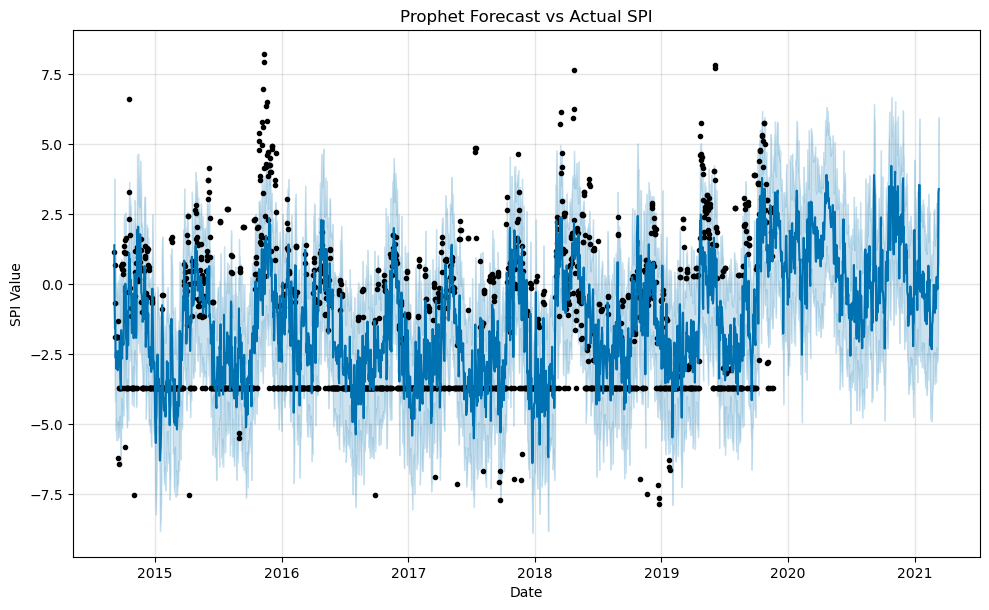

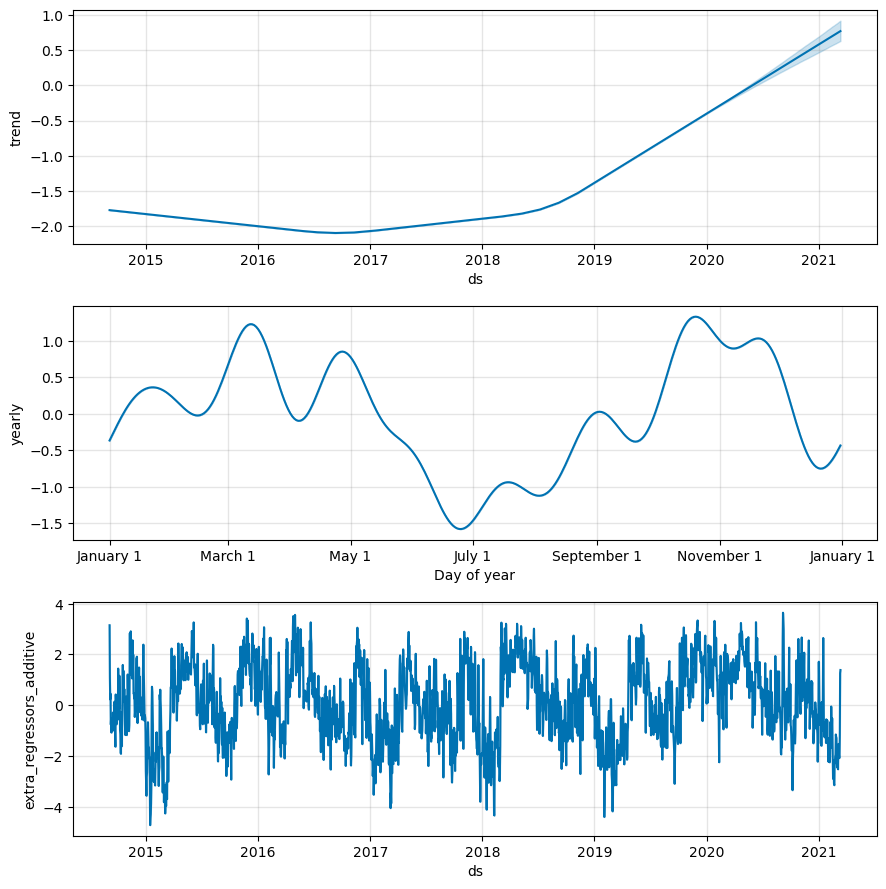

In [12]:
# 9. Visualize Results
fig = model.plot(forecast)
plt.title('Prophet Forecast vs Actual SPI')
plt.xlabel('Date')
plt.ylabel('SPI Value')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()



In [13]:
# 10. Drought Classification Evaluation
# Convert SPI to drought classification (1 = drought, 0 = no drought)
results['actual_class'] = (results['y'] <= -1.0).astype(int)
results['predicted_class'] = (results['yhat'] <= -1.0).astype(int)

# Calculate classification metrics
from sklearn.metrics import classification_report
print("\nDrought Classification Report:")
print(classification_report(results['actual_class'], results['predicted_class']))




Drought Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.72       958
           1       0.83      0.77      0.79      1423

    accuracy                           0.76      2381
   macro avg       0.76      0.76      0.76      2381
weighted avg       0.77      0.76      0.77      2381



In [14]:
# 11. Feature Importance Analysis
# Prophet doesn't provide direct feature importance, but it can be analyzed with the regressor coefficients
regressor_coeffs = pd.DataFrame({
    'regressor': ['temp', 'humidity', 'windspeed'],
    'coefficient': [model.params['beta'][0][i] for i in range(3)]
})

print("\nRegressor Coefficients:")
print(regressor_coeffs.sort_values('coefficient', key=abs, ascending=False))


Regressor Coefficients:
   regressor  coefficient
1   humidity     0.075341
2  windspeed    -0.029059
0       temp     0.006882


In [15]:
#Add more features
df['rolling_3m_temp'] = df['temp'].rolling(window=90).mean()
df['rolling_12m_precip'] = df['y'].rolling(window=365).sum()

In [16]:
#Implement LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Use Prophet's trend+seasonal components as features for LSTM
lstm_features = forecast[['trend', 'yearly', 'additive_terms']]
# Combine with original features and build LSTM model

In [17]:
#Hyperparameter tuning

from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)
print(df_p.head())

  0%|          | 0/5 [00:00<?, ?it/s]

10:10:25 - cmdstanpy - INFO - Chain [1] start processing
10:10:25 - cmdstanpy - INFO - Chain [1] done processing
10:10:25 - cmdstanpy - INFO - Chain [1] start processing
10:10:25 - cmdstanpy - INFO - Chain [1] done processing
10:10:26 - cmdstanpy - INFO - Chain [1] start processing
10:10:26 - cmdstanpy - INFO - Chain [1] done processing
10:10:26 - cmdstanpy - INFO - Chain [1] start processing
10:10:27 - cmdstanpy - INFO - Chain [1] done processing
10:10:27 - cmdstanpy - INFO - Chain [1] start processing
10:10:27 - cmdstanpy - INFO - Chain [1] done processing


  horizon       mse      rmse       mae      mape     mdape     smape  \
0 37 days  4.714967  2.171397  1.719666  3.799100  0.526880  0.872868   
1 38 days  4.555390  2.134336  1.692825  3.567970  0.513101  0.839338   
2 39 days  4.505172  2.122539  1.687253  3.573423  0.513101  0.836821   
3 40 days  4.551436  2.133409  1.694394  3.693755  0.513101  0.828926   
4 41 days  4.685470  2.164595  1.726309  3.772764  0.519610  0.831786   

   coverage  
0  0.735165  
1  0.746154  
2  0.750549  
3  0.741758  
4  0.730769  


In [18]:
# Deployment planning
import joblib

# Save the model
joblib.dump(model, 'drought_prophet_model.pkl')

# To load later:
model = joblib.load('drought_prophet_model.pkl')

Streamlit Deployment

Create a requirements.txt file

In [ ]:
streamlit>=1.22.0
pandas>=1.5.0
numpy>=1.23.0
prophet>=1.1.0
plotly>=5.11.0
scikit-learn>=1.1.0
matplotlib>=3.6.0
joblib>=1.2.0

Run the Application

In [ ]:
# pip install -r requirements.txt

# streamlit run drought_app.py